In [2]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
# TESTING_FOLDER = Path.home() / Path("Desktop/testing")
TESTING_FOLDER = Path("testing/")
METADATA_PATH = TESTING_FOLDER / "metadata.xlsx"

In [4]:
df = pd.read_excel(METADATA_PATH)
id_map = {row.Path: i for i, row in enumerate(df.itertuples(index=False))}
df["id"] = df["Path"].map(id_map)
df

,Path,Description,id
0,1.jpg,"orange cat covers its face with a paw, underne...",0
1,2.jpg,"dog lies in its bed, that is placed on the carpet",1
2,3.jpg,"a tree-shaped-like anthenna, text on the image...",2
3,4.jpg,"a cat with a terrified expression on its face,...",3
4,5.jpg,a drawing of a dog with the bubble over its he...,4
5,6.jpg,"a comic, cat says meow to the woman, woman say...",5
6,7.jpg,image of a man with a mask and a shirt that sa...,6
7,8.jpg,tweet of graph of an lg washing machine intern...,7
8,9.jpg,"""are you winning son?"" meme",8
9,10.jpg,post about computer safety from a trans person,9


In [5]:
TOP_K = 4

In [6]:
def reciprocal_rank(results, correct_id):
    try:
        rank = results.index(correct_id) + 1
        return 1 / rank
    except ValueError:
        return 0.0
    
def hit_at_k(results, correct_id, k):
    return int(correct_id in results[:k])

In [7]:
from cli.platform_file_revealer import PlatformFileRevealer
from cli.table_maker import TableMaker
from infrastructure.services.multimedia_type_detector import MultimediaTypeFinder
from infrastructure.bge_small_encoder import BGEEncoder
from infrastructure.qdrant.qdrant_vdb import QdrantVectorDatabase
from infrastructure.qdrant.qdrant_output_processor import QdrantOutputProcessor
from infrastructure.ml.device import get_device_config
from cli.cli_decoder import CLIDecoder
from settings import *

from dotenv import load_dotenv
import os


load_dotenv("config.env")
hf_token = os.getenv("HF_TOKEN")
config = get_device_config()

encoder = BGEEncoder(hf_token, config)
db = QdrantVectorDatabase()
mtf = MultimediaTypeFinder()

output_processor = QdrantOutputProcessor()
table_maker = TableMaker()
revealer = PlatformFileRevealer()

/Users/williamleonheart/Documents/multimedia-by-prompt-search/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1367.44it/s]


In [8]:
N = len(df)

hit_matrices = {
    k: pd.DataFrame(
        0,
        index=range(N),
        columns=range(N),
        dtype=int
    )
    for k in range(1, TOP_K + 1)
}

In [9]:
for row in df.itertuples(index=False):
    target_id = row.id
    query_text = row.Description
    real_path = row.Path

    embedding = encoder.encode(query_text)
    results = db.search(embedding, TOP_K)

    rows = output_processor.create_dict_of_rows(results)

    print("\n" + "=" * 120)
    print(f"QUERY (real description): {query_text}")
    print(f"GROUND TRUTH PATH: {real_path}")
    print(f"GROUND TRUTH ID: {target_id}")

    print("\nTOP RESULTS:")

    retrieved_ids = []

    for rank, r in enumerate(rows):
        path = r.get("path")
        db_desc = r.get("text_description", None)
        score = r.get("score", None)

        file_id = id_map.get(Path(path).name) if path else None
        retrieved_ids.append(file_id)

        print(f"\nRank {rank + 1}")
        print(f"Path: {path}")
        print(f"DB Description: {db_desc}")
        print(f"Score: {score}")
        print(f"Mapped ID: {file_id}")

        for k in range(1, TOP_K + 1):
            if target_id in retrieved_ids[:k]:
                hit_matrices[k].loc[target_id, target_id] = 1

    hit1 = hit_at_k(retrieved_ids, target_id, 1)
    print(f"\nHIT@1: {hit1}")


QUERY (real description): orange cat covers its face with a paw, underneath it there is an emoji with the same expression
GROUND TRUTH PATH: 1.jpg
GROUND TRUTH ID: 0

TOP RESULTS:

Rank 1
Path: testing/4.jpg
DB Description: This humorous photo features a close-up of a young Asian cat, likely with a tabby pattern, with white fur around its eyes and nose. The cat's striking greenish hues are accentuated with the lighting. The kitten’s eyes are notably wide open, giving it an excited or alert expression, reminiscent of a cat
Score: 0.7310386282771437
Mapped ID: 3

Rank 2
Path: testing/1.jpg
DB Description: The image is an extremely close-up photo of a cat, likely a Staffordshire Bull Terrier, characterized by its orange-brown fur with distinct white striping on its chest. The cat's head is the focal point, with a mix of brown and blonde fur. Its gaze appears intense and almost menacing, as if
Score: 0.7156862833286352
Mapped ID: 0

Rank 3
Path: testing/vid_7.MP4
DB Description: In the im

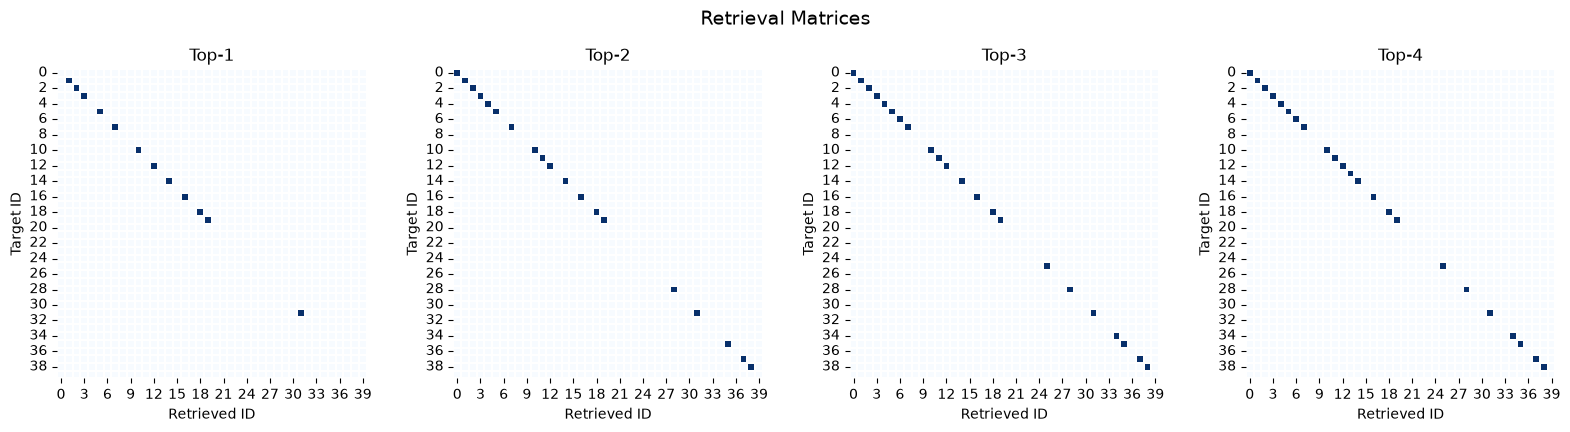

In [10]:
import math

fig_cols = TOP_K
fig_rows = math.ceil(len(hit_matrices) / fig_cols)

fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(fig_cols * 4, fig_rows * 4))
axes = axes.flatten()

for idx, (k, matrix) in enumerate(hit_matrices.items()):
    sns.heatmap(
        matrix,
        ax=axes[idx],
        cmap="Blues",
        square=True,
        cbar=False,
        linewidths=0.2,
    )
    axes[idx].set_title(f"Top-{k}")
    axes[idx].set_xlabel("Retrieved ID")
    axes[idx].set_ylabel("Target ID")

for idx in range(len(hit_matrices), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Retrieval Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
len(df)

40

In [41]:
all_paths = []

for row in df.itertuples(index=False):
    target_id = row.id
    query_text = row.Description
    real_path = row.Path
    
    all_paths.append(real_path)

    embedding = encoder.encode(query_text)
    results = db.search(embedding, len(df))

    rows = output_processor.create_dict_of_rows(results)

    processed_rows = []

    for rank, r in enumerate(rows):
        path = r.get("path")
        name = str(Path(path).name)
        db_desc = r.get("text_description")
        score = r.get("score")

        file_id = id_map.get(Path(path).name)
        processed_rows.append([name, score])


    print(rows)

[{'path': 'testing/4.jpg', 'score': '0.7310386282771437', 'text_description': "This humorous photo features a close-up of a young Asian cat, likely with a tabby pattern, with white fur around its eyes and nose. The cat's striking greenish hues are accentuated with the lighting. The kitten’s eyes are notably wide open, giving it an excited or alert expression, reminiscent of a cat"}, {'path': 'testing/1.jpg', 'score': '0.7156862833286353', 'text_description': "The image is an extremely close-up photo of a cat, likely a Staffordshire Bull Terrier, characterized by its orange-brown fur with distinct white striping on its chest. The cat's head is the focal point, with a mix of brown and blonde fur. Its gaze appears intense and almost menacing, as if"}, {'path': 'testing/vid_7.MP4', 'score': '0.7113099493484966', 'text_description': 'In the image, a domesticated orange cat with dark stripes is prominently featured lying on a bed. The cat extends its front paws and ears forward, as its face 

In [ ]:
matrix_rows = []
row_names = []

for row in df.itertuples(index=False):
    target_id = row.id
    query_text = row.Description
    real_path = row.Path

    embedding = encoder.encode(query_text)
    results = db.search(embedding, len(df))

    rows = output_processor.create_dict_of_rows(results)

    processed_rows = []
    for r in rows:
        path = r["path"]
        name = Path(path).name
        score = float(r["score"])

        processed_rows.append([name, score])

    scores_df = pd.DataFrame(processed_rows, columns=["name", "score"])

    scores_df["type"] = scores_df["name"].str.startswith("vid_").map(
        {True: "video", False: "image"}
    )
    scores_df["index"] = scores_df["name"].str.extract(r"(\d+)").astype(int)

    scores_df = (
        scores_df.sort_values(
            by=["type", "index"],
            key=lambda s: s.map({"image": 0, "video": 1}) if s.name == "type" else s,
        )
        .reset_index(drop=True)
    )

    matrix_rows.append(scores_df.set_index("name")["score"])
    row_names.append(real_path)

score_df = pd.DataFrame(matrix_rows, index=row_names)
score_matrix = score_df.to_numpy()


In [39]:
score_df

name,1.jpg,2.jpg,3.jpg,4.jpg,5.jpg,6.jpg,7.jpg,8.jpg,9.jpg,10.jpg,...,vid_11.mp4,vid_12.MP4,vid_13.mp4,vid_14.mp4,vid_15.mp4,vid_16.mp4,vid_17.mp4,vid_18.mp4,vid_19.mp4,vid_20.mp4
1.jpg,0.715686,0.512674,0.515991,0.731039,0.610029,0.621106,0.543422,0.483238,0.542664,0.548313,...,0.518895,0.666274,0.407282,0.558671,0.510130,0.514389,0.516132,0.555313,0.465757,0.514004
2.jpg,0.540441,0.716484,0.402075,0.512875,0.492447,0.504219,0.471501,0.406594,0.484334,0.440881,...,0.442027,0.617096,0.416352,0.388914,0.411462,0.433567,0.395430,0.434381,0.410629,0.426669
3.jpg,0.582388,0.507666,0.772782,0.580950,0.581754,0.559737,0.626499,0.570192,0.649336,0.588547,...,0.607823,0.631571,0.518030,0.576334,0.573281,0.561318,0.558714,0.650667,0.579320,0.567732
4.jpg,0.680973,0.526981,0.526124,0.727461,0.623570,0.646289,0.614440,0.500044,0.583071,0.568844,...,0.511790,0.676543,0.457203,0.601566,0.553987,0.543855,0.502084,0.583152,0.507395,0.495098
5.jpg,0.615191,0.539402,0.520298,0.536685,0.615501,0.592352,0.595582,0.536371,0.561428,0.527005,...,0.484457,0.617583,0.445084,0.512223,0.521426,0.512465,0.501580,0.593263,0.506595,0.524486
6.jpg,0.603111,0.457870,0.490308,0.652629,0.659509,0.700552,0.515273,0.449814,0.516787,0.463850,...,0.438019,0.578826,0.446430,0.579373,0.461536,0.512690,0.416968,0.574646,0.424527,0.450365
7.jpg,0.490422,0.427298,0.508199,0.477508,0.424251,0.475079,0.619606,0.457536,0.637216,0.610189,...,0.460420,0.514793,0.606408,0.557482,0.517890,0.509931,0.463314,0.576814,0.426651,0.430969
8.jpg,0.407537,0.463033,0.478721,0.456150,0.455220,0.421868,0.457825,0.756848,0.452186,0.516917,...,0.516567,0.432219,0.424526,0.465368,0.527867,0.468361,0.536801,0.529258,0.525906,0.486922
9.jpg,0.451193,0.381008,0.542258,0.499478,0.473844,0.486676,0.583262,0.572673,0.548102,0.572903,...,0.499466,0.470304,0.508426,0.644301,0.510186,0.517115,0.495089,0.595661,0.557858,0.519929
10.jpg,0.461091,0.415865,0.494865,0.482691,0.478584,0.469602,0.518780,0.596216,0.550024,0.548973,...,0.491624,0.435981,0.446563,0.523619,0.518432,0.519786,0.475817,0.553689,0.486377,0.496180


<Axes: >

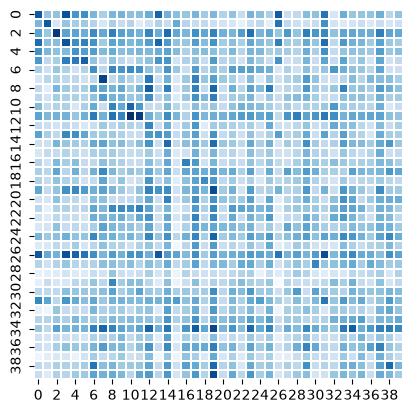

In [38]:
sns.heatmap(
        score_matrix,
        cmap="Blues",
        square=True,
        cbar=False,
        linewidths=0.2,
    )

In [11]:
db.client.close()